# Balanced Random Forest Classification

## Objective

The objective of this notebook is to build a Balanced Random Forest classifier to predict whether a loan is:

- Performing (1)
- Non-Performing (0)

Because the dataset is highly imbalanced, the model uses **class_weight="balanced"** to assign greater importance to the minority class during training.

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Classification Report
- Confusion Matrix
- Feature Importance

The results are compared with the standard Random Forest and Balanced Logistic Regression models.

In [1]:
# IMPORT LIBRARIES


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# LOAD DATASET


df = pd.read_csv("clean_loanset.csv")

In [3]:
# CREATE TARGET VARIABLE


df["Target"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Current", "Fully Paid"] else 0
)

In [4]:
# CHECK CLASS DISTRIBUTION


print(df["Target"].value_counts())

print()

print(round(df["Target"].value_counts(normalize=True)*100,2))

Target
1    9822
0     178
Name: count, dtype: int64

Target
1    98.22
0     1.78
Name: proportion, dtype: float64


In [5]:
# CREATE TERM GROUP


df["term_group"] = df["term"].apply(
    lambda x: "Short Term" if "36" in str(x) else "Long Term"
)

In [6]:
# SELECT FEATURES


features = [

    "loan_amount",

    "interest_rate",

    "consolidated_annual_income",

    "consolidated_debt_to_income",

    "delinq_2y",

    "months_since_last_delinq",

    "inquiries_last_12m",

    "tax_liens",

    "num_historical_failed_to_pay",

    "loan_purpose",

    "application_type",

    "homeownership",

    "consolidated_verified_income",

    "term_group"

]

In [7]:
# ONE HOT ENCODE


X = pd.get_dummies(
    df[features],
    drop_first=True
)

y = df["Target"]

In [8]:
# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [9]:
# TRAIN BALANCED RANDOM FOREST


rf = RandomForestClassifier(

    n_estimators=300,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# PREDICTIONS


y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [11]:
# MODEL PERFORMANCE


print("Accuracy :", round(accuracy_score(y_test,y_pred),3))

print("Precision:", round(precision_score(y_test,y_pred),3))

print("Recall   :", round(recall_score(y_test,y_pred),3))

print("F1 Score :", round(f1_score(y_test,y_pred),3))

print()

print("ROC AUC :", round(roc_auc_score(y_test,y_prob),3))

Accuracy : 0.982
Precision: 0.982
Recall   : 1.0
F1 Score : 0.991

ROC AUC : 0.689


In [12]:
# CLASSIFICATION REPORT


print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
# CONFUSION MATRIX


cm = confusion_matrix(y_test,y_pred)

print(cm)

[[   0   36]
 [   0 1964]]


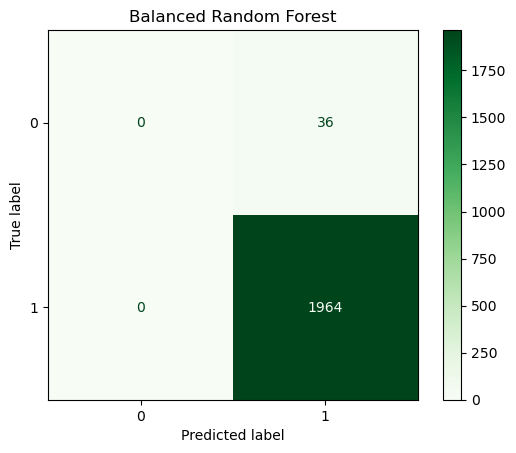

In [14]:
# PLOT CONFUSION MATRIX


disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Balanced Random Forest")

plt.show()

In [15]:
# FEATURE IMPORTANCE


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
1,interest_rate,0.189522
3,consolidated_debt_to_income,0.147199
2,consolidated_annual_income,0.143385
0,loan_amount,0.126443
5,months_since_last_delinq,0.077276
6,inquiries_last_12m,0.070421
24,consolidated_verified_income_Verified,0.026875
23,consolidated_verified_income_Source Verified,0.022989
22,homeownership_RENT,0.021586
25,term_group_Short Term,0.020945


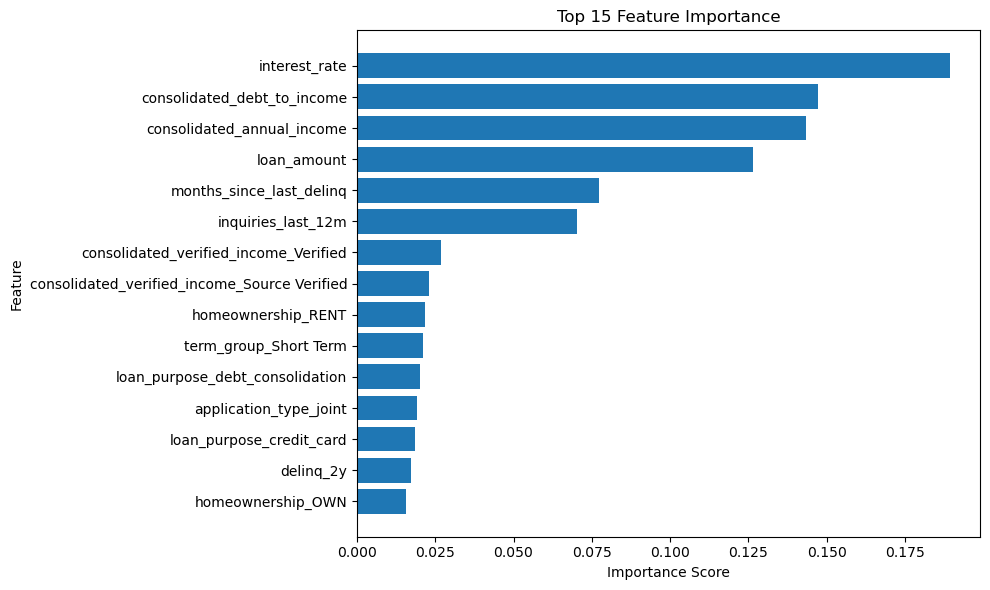

In [16]:
# PLOT FEATURE IMPORTANCE


top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.title("Top 15 Feature Importance")

plt.tight_layout()

plt.show()

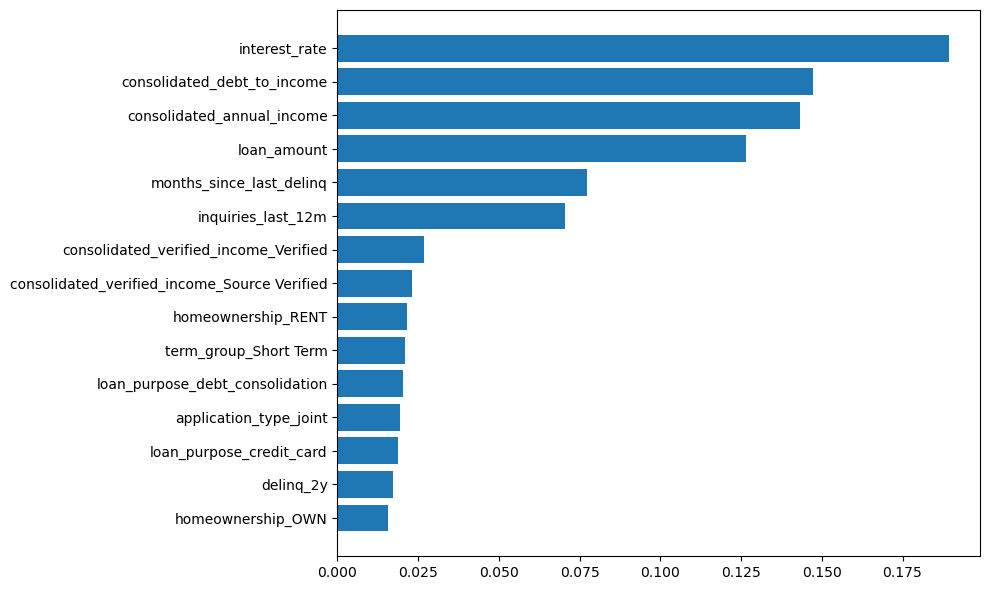

In [17]:
# SAVE FEATURE IMPORTANCE


plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Importance"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(

    "balanced_random_forest_feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [18]:
# EXPORT FEATURE IMPORTANCE


importance.to_csv(

    "balanced_random_forest_feature_importance.csv",

    index=False

)

print("Feature importance exported successfully.")

Feature importance exported successfully.


# Interpretation

The Balanced Random Forest model was trained using class weighting to address the severe class imbalance in the lending dataset, where approximately **98.22%** of loans were performing and **1.78%** were non-performing.

The model achieved the following performance:

- **Accuracy:** 98.2%
- **Precision:** 98.2%
- **Recall:** 100.0%
- **F1 Score:** 99.1%
- **ROC AUC:** 0.689

Although the overall accuracy and F1 Score appear very high, the confusion matrix reveals that the model classified every loan as **Performing** and failed to identify any **Non-Performing** loans. All **36 non-performing loans** were incorrectly predicted as performing, while all **1,964 performing loans** were classified correctly.

This demonstrates that the model remained heavily influenced by the majority class despite the use of balanced class weights. Consequently, the high accuracy is misleading and does not reflect effective credit risk prediction.

The ROC AUC score of **0.689** indicates only moderate discriminatory ability and further confirms that the model has limited effectiveness in distinguishing between performing and non-performing loans.

Overall, these results show that applying `class_weight="balanced"` alone was insufficient to improve the Random Forest model on this highly imbalanced dataset.

# Business Insight

In credit risk assessment, the primary objective is to identify borrowers who are likely to default rather than simply maximizing overall prediction accuracy.

The Balanced Random Forest model highlights one of the key challenges associated with highly imbalanced datasets. Despite applying balanced class weights, the model continued to classify every loan as performing, resulting in the complete failure to detect high-risk borrowers.

This finding suggests that class weighting alone was insufficient to overcome the severe imbalance in the dataset. Additional techniques such as Synthetic Minority Oversampling Technique (SMOTE), random undersampling, threshold adjustment, or hyperparameter tuning may be required to improve the identification of non-performing loans.

The analysis also demonstrates why confusion matrices, ROC AUC, Precision, Recall, and F1 Score should be considered alongside accuracy when evaluating classification models in credit risk applications.

These findings emphasize the importance of selecting evaluation metrics that align with the business objective rather than relying solely on overall model accuracy.

# Conclusion

The Balanced Random Forest model was developed to improve the prediction of non-performing loans in a highly imbalanced lending dataset. However, despite incorporating balanced class weights, the model continued to classify every loan as performing.

Although the model achieved an overall accuracy of **98.2%**, it failed to correctly identify any of the **36 non-performing loans** in the test dataset. This demonstrates that high accuracy alone is not an appropriate indicator of model performance when working with imbalanced classification problems.

Compared with the Balanced Logistic Regression model, which successfully identified approximately **69%** of the non-performing loans, the Balanced Random Forest model proved less effective for this credit risk prediction task.

Overall, the results demonstrate that different machine learning algorithms respond differently to class imbalance techniques. In this project, **Balanced Logistic Regression provided the most practical classification model for detecting high-risk borrowers**, making it the preferred model for supporting lending decisions and portfolio risk management.